# Using the Kemeny constant as robustness measure in networks with destinations and intersections

## Setting

We model a trafic network as a time-weighted Markov chain. The core objective is to perform a **sequential $N-k$ failure analysis** to quantify the network resilience. Unlike static failure analyses, this framework is adaptive: following a disruption (road closure), the system attempts to "heal" itself by optimizing the speed limits (time-weights) of the remaining roads to restore global efficiency and reliability.

### Framework
The network is represented as a time-weighted Markov chain $(P,W)$ on a graph $G = (V, E)$ where $W$ is a time-weight matrix that is inversely related to the speed limit on each road. The stationary distribution of $P$, which we will denote by $\pi^*$ is an important quanitity, as this captures the average behavior of the system, i.e., where traffic initially wants to go. In this initial state, the network has connectivity,
\begin{align}
K^t (P, W, \pi^*, Z) = {\rm tr}(Z)\cdot \pi^* (P\circ W) \vec{\bf 1}\, .
\end{align}

In the context of road networks, a "failure" could be caused by an accident on that road, construction, maintenance, or any other event that would render the road unusable. This fundamentally alters the original network's topology, creating a new transition matrix $P_1$ where $P_1(i,j) = 0$ for some $(i,j) \in E$ for which $P(i,j)>0$. Now, the matrix $P_1$ is not a valid transition matrix anymore, so we have to project it in order to be feasible. We can choose to,
1. (Short-term) project $P_1$ "naively" and simply renormalize each row, however, this might cause deviations in the stationary distribution $\pi_1$. This should be fine as long as $\pi_1 \approx \pi^*$. Interpretation wise, this would be equivalent to saying the drivers haven't had the time to plan ahead based on the failure, and must make a new choice at the nearest intersection.
2. (Long-term) project $P_1$ to its nearest counterpart $\tilde P_1$ with stationary distribution $\pi^*$, though this, in its own, can cause strong deviations in the Kemeny constant. Interpretation wise, this means that drivers already know of the failure and pre-plan a different route, achieving $\pi^*$.
3. Combination: we distinguish destination $D$ and intersection $I$ nodes, such that $I \cup D = V$ and $I \cap D = \emptyset$. We want to fix the stationary distribution at the destination nodes, while freely optimizing over the intersection nodes.

After the disruption, our goal is to find a new suitable time-weight matrix $W_1$ that will result in **no decrease** in the network connectivity. Mind you, we do not seek to find an *optimal* choice for $W_1$, we merely seek a minimal change in the time-weights, such that the Kemeny constant (and its variance) are at least not worse, i.e., we satisfy the Constraint Minimal Intervention program,
\begin{align}
\min_{W} \quad & ||W - W_{k}||^2 \\
 \text{s.t.} \quad & K^t(P_k, W_k, \pi^*, Z) \leq K^t(P, W, \pi^*, Z) \\ 
 & V^t(P_k, W) \leq V^t(P, W) \\
  & W_{min} \leq W \leq W_{max}\, ,
\end{align}
where $V^t(P, W)$ denotes the second-order Kemeny constant.

In [ ]:
import numpy as np
import math
import sys
import matplotlib.pyplot as plt
import networkx  as nx
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import random

if 'functions' in sys.modules:
    del sys.modules['functions']
import functions as fn

if 'projections' in sys.modules:
    del sys.modules['projections']
import projections

if 'minimal_optimization' in sys.modules:
    del sys.modules['minimal_optimization']
import minimal_optimization as mo

if 'hybrid_projection' in sys.modules:
    del sys.modules['hybrid_projection']
import hybrid_projection as hp

In [2]:
'''
Model Parameter Configuration Module
'''

random_seed = 18112000
np.random.seed(random_seed)

#graph
num_nodes = 10
avg_degree = 25
connection_prob = np.sqrt(avg_degree / (np.pi * num_nodes))

#weights (and optimization range)
bot = 5
top = 50
weight_range = 0.33 #20%

#max number of failures to simulate
K = 10

destinations = [1, 4, 8]

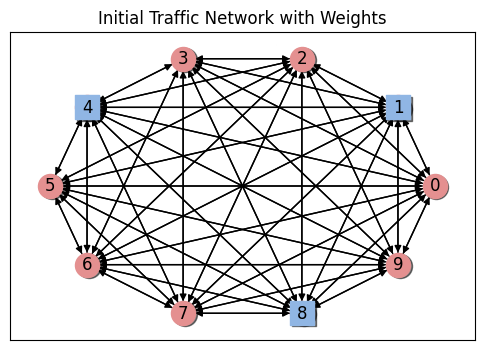

Target stationary distribution (pi*): [0.10227273 0.10227273 0.10227273 0.09090909 0.10227273 0.09090909
 0.10227273 0.10227273 0.10227273 0.10227273]


In [3]:
P = fn.generate_transition_matrix(num_nodes, connection_prob, random_seed)
W = np.random.rand(num_nodes, num_nodes) * (top - bot) + bot
W_min = W * (1 - weight_range)
W_max = W * (1 + weight_range)

_ = fn.plot_graph(P, W, destinations, "Initial Traffic Network with Weights")

#target stationary distribution
pi_star = fn.stationary_distribution(P)
print("Target stationary distribution (pi*):", pi_star)

## Single N-k run for destination/ intersection setup

Code for doing a single run:

In [ ]:
def single_hybrid_run(
    P_init, destinations, W_init, W_min, W_max, k_max
):
    """
    Single N-k failure resilience run using Proj(Pi*) projection followed by
    minimal intervention weight optimization.

    Parameters:
    - P_init, W_init: Initial state.
    - destinations: List of destination node indices.
    - W_min, W_max: Bounds.
    - k_max: Number of failures to simulate.
    """

    N = P_init.shape[0]

    # 1. SETUP
    pi_star = fn.stationary_distribution(P_init)

    # Generate the failure sequence
    G = nx.from_numpy_array(P_init, create_using=nx.DiGraph)
    edges = list(G.edges())
    np.random.shuffle(edges)

    k_actual = min(k_max, len(edges))
    failure_sequence = edges[:k_actual]

    # Ensure graph stays strongly connected after all removals
    G_temp = G.copy()
    G_temp.remove_edges_from(failure_sequence)

    max_attempts = 1000000
    attempts = 0
    while not nx.is_strongly_connected(G_temp) and attempts < max_attempts:
        np.random.shuffle(edges)
        failure_sequence = edges[:k_actual]
        G_temp = G.copy()
        G_temp.remove_edges_from(failure_sequence)
        attempts += 1

    if attempts >= max_attempts:
        print(f"Warning: Could not find strongly connected removal after {max_attempts} attempts.")
        print(f"Reducing k_actual from {k_actual} to {k_actual - 1}")
        k_actual = max(1, k_actual - 1)
        failure_sequence = edges[:k_actual]

    print(f"Generated failure sequence of {k_actual} edges that does not disconnect the graph: {failure_sequence}.")
    print(f"Simulation initialized for N-{k_actual} analysis.")

    # 2. STATE & HISTORY
    P_curr = P_init.copy()
    W_curr = W_init.copy()

    k_axis = []
    K_opt_hist = []
    K_unopt_hist = []
    V_opt_hist = []
    V_unopt_hist = []

    # Initial values (k=0)
    K0 = fn.kemeny_constant(P_curr, pi_star, W_curr)
    V0 = fn.variance_based_kemeny(P_curr, pi_star, W_curr, W_curr**2)
    k_axis.append(0)
    K_opt_hist.append(K0)
    K_unopt_hist.append(K0)
    V_opt_hist.append(V0)
    V_unopt_hist.append(V0)

    # 3. SIMULATION
    for k, (u, v) in tqdm(enumerate(failure_sequence, 1)):
        # A. Remove edge
        P_curr[u, v] = 0.0

        if np.sum(P_curr[u, :]) == 0:
            print(f"  -> Terminated at k={k}: Node {u} isolated.")
            break

        # B. Project to hybrid target distribution
        get_hybrid_target_distribution = hp.get_hybrid_target(P_curr, pi_star, destinations)
        
        P_new = projections.project_P(P_curr, get_hybrid_target_distribution, verbose=False)
        if P_new is None:
            print(f"  -> Terminated at k={k}: Projection infeasible.")
            break
        P_curr = P_new

        # C. Measure unoptimized (projected topology, original weights)
        try:
            K_unopt = fn.kemeny_constant(P_curr, pi_star, W_init)
            V_unopt = fn.variance_based_kemeny(P_curr, pi_star, W_init, W_init**2)
        except:
            print(f"  -> Terminated at k={k}: Graph reducible (K calc failed).")
            break

        # D. Minimal intervention weight optimization
        W_new = mo.optimize_edge_weights(
            P_new=P_curr,
            pi_star=pi_star,
            W_current=W_curr,
            W_init=W_init,
            P_init=P_init,
            W_min=W_min, W_max=W_max
        )

        if W_new is None:
            print(f"  -> Terminated at k={k}: Optimization failed (constraints too tight).")
            break

        W_curr = W_new
        K_opt = fn.kemeny_constant(P_curr, pi_star, W_curr)
        V_opt = fn.variance_based_kemeny(P_curr, pi_star, W_curr, W_curr**2)

        k_axis.append(k)
        K_unopt_hist.append(K_unopt)
        K_opt_hist.append(K_opt)
        V_unopt_hist.append(V_unopt)
        V_opt_hist.append(V_opt)

        P_latest = P_curr.copy()

    # 4. PLOTTING
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    # Col 1: Kemeny (Opt vs Unopt)
    axes[0].plot(k_axis, K_unopt_hist, 'r--', label='Unoptimized', alpha=0.7)
    axes[0].plot(k_axis, K_opt_hist, 'g-o', label='Optimized', linewidth=2)
    axes[0].set_title("Kemeny Constant")
    axes[0].set_xlabel("Number of Removed Edges (k)")
    axes[0].set_ylabel("Kemeny Constant")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Col 2: Per-component stationary distribution deviation at final state
    pi_final = fn.stationary_distribution(P_latest)
    pi_diff_components = pi_final - pi_star
    node_indices = np.arange(N)
    colors = ['tab:orange' if i in destinations else 'tab:blue' for i in node_indices]
    axes[1].bar(node_indices, pi_diff_components, color=colors)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"Final Stat. Dist. Deviation (π_final − π*)\nafter k={k_axis[-1]} failures")
    axes[1].set_xlabel("Node")
    axes[1].set_ylabel("Δπ per component")
    axes[1].set_xticks(node_indices)
    from matplotlib.patches import Patch
    axes[1].legend(handles=[
        Patch(facecolor='tab:orange', label='Destination'),
        Patch(facecolor='tab:blue', label='Intersection')
    ])
    axes[1].grid(True, alpha=0.3, axis='y')

    # Col 3: Variance (Opt vs Unopt)
    axes[2].plot(k_axis, V_unopt_hist, 'r--', label='Unoptimized', alpha=0.7)
    axes[2].plot(k_axis, V_opt_hist, color='purple', marker='s', label='Optimized', linewidth=2)
    axes[2].set_title("Kemeny Variance")
    axes[2].set_xlabel("Number of Removed Edges (k)")
    axes[2].set_ylabel("Kemeny Variance")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle("Hybrid Proj + Minimal Intervention: N-k Resilience", fontsize=13)
    plt.show()

In [5]:
#single_hybrid_run(P, destinations, W, W_min, W_max, K)

## Three-way comparison between naive, π* and hybrid

## Three-Way Strategy Comparison: $\pi^*$, Naive, and Hybrid Projection

We now compare all three projection strategies under the same random failure sequence, each paired with minimal intervention weight optimisation:

1. **Proj($\pi^*$) + Minimal** — project the broken topology to its nearest stochastic matrix that preserves *exactly* the original stationary distribution $\pi^*$.
2. **Naive + Minimal** — row-normalise the broken topology (no stationary-distribution constraint); $\pi$ is allowed to drift.
3. **Hybrid + Minimal** — lock the $\lceil N/4 \rceil$ highest-traffic *destination* nodes to their $\pi^*$ values while letting intersection nodes drift freely; project to this hybrid target.

For each strategy we plot:
- **Kemeny constant** (optimised vs. unoptimised) over the failure sequence,
- **Component-wise stationary-distribution deviation** $\pi_{\text{final}} - \pi^*$ at the last successfully handled failure, and
- **Kemeny variance** (optimised vs. unoptimised) over the failure sequence.

In [ ]:
def compare_nk_strategies_three(
    P_init, W_init, W_min, W_max, k_max, destinations=None
):
    """
    Compares three N-k resilience strategies on the same failure sequence, all
    paired with minimal intervention weight optimisation:
      1. Proj(Pi*) + Minimal   – project to exact pi*
      2. Naive + Minimal       – row-normalise (pi allowed to drift)
      3. Hybrid + Minimal      – lock destination nodes to pi*, free intersections

    Parameters
    ----------
    P_init, W_init : Initial transition matrix and weight matrix.
    W_min, W_max   : Element-wise weight bounds.
    k_max          : Maximum number of edges to remove.
    destinations   : Array of node indices treated as destinations in the hybrid
                     strategy. Defaults to the ceil(N/4) nodes with highest pi*.
    """
    import math

    N = P_init.shape[0]
    pi_star = fn.stationary_distribution(P_init)

    # Default destinations: top ceil(N/4) nodes by pi* mass
    if destinations is None:
        n_dest = max(1, math.ceil(N / 4))
        destinations = np.argsort(pi_star)[-n_dest:]
    destinations = np.asarray(destinations)

    # ── Generate the failure sequence (same for all strategies) ───────────────
    G = nx.from_numpy_array(P_init, create_using=nx.DiGraph)
    edges = list(G.edges())
    np.random.shuffle(edges)

    k_actual = min(k_max, len(edges))
    failure_sequence = edges[:k_actual]

    G_temp = G.copy()
    G_temp.remove_edges_from(failure_sequence)

    max_attempts = 1_000_000
    attempts = 0
    while not nx.is_strongly_connected(G_temp) and attempts < max_attempts:
        np.random.shuffle(edges)
        failure_sequence = edges[:k_actual]
        G_temp = G.copy()
        G_temp.remove_edges_from(failure_sequence)
        attempts += 1

    if attempts >= max_attempts:
        print(f"Warning: could not find a strongly-connected removal after "
              f"{max_attempts} attempts.")
        k_actual = max(1, k_actual - 1)
        failure_sequence = edges[:k_actual]

    print(f"Failure sequence ({k_actual} edges, graph stays strongly connected): "
          f"{failure_sequence}")
    print(f"Destination nodes (hybrid): {destinations.tolist()}")

    # ── Strategy definitions ───────────────────────────────────────────────────
    strategies = [
        ("Proj($\\pi^*$) + Minimal", "proj_pi"),
        ("Naive + Minimal",            "naive"),
        ("Hybrid + Minimal",           "hybrid"),
    ]

    results = {}

    # ── Run each strategy ──────────────────────────────────────────────────────
    for name, stype in strategies:
        print(f"Running strategy: {name} ...")

        P_curr = P_init.copy()
        W_curr = W_init.copy()

        k_axis        = [0]
        K_opt_hist    = [fn.kemeny_constant(P_curr, pi_star, W_curr)]
        K_unopt_hist  = [K_opt_hist[0]]
        V_opt_hist    = [fn.variance_based_kemeny(P_curr, pi_star, W_curr, W_curr**2)]
        V_unopt_hist  = [V_opt_hist[0]]
        pi_final      = pi_star.copy()          # updated at every successful step

        for k, (u, v) in enumerate(failure_sequence, 1):
            P_curr[u, v] = 0.0

            # ── Isolation check ────────────────────────────────────────────────
            if np.sum(P_curr[u, :]) == 0:
                print(f"  -> Terminated at k={k}: node {u} isolated.")
                break

            # ── Projection ────────────────────────────────────────────────────
            if stype == "proj_pi":
                P_new = projections.project_P(P_curr, pi_star, verbose=False)
                if P_new is None:
                    print(f"  -> Terminated at k={k}: Pi* projection infeasible.")
                    break
                P_curr    = P_new
                pi_active = pi_star.copy()

            elif stype == "naive":
                row_sums = P_curr.sum(axis=1, keepdims=True)
                row_sums[row_sums == 0] = 1.0
                P_curr = P_curr / row_sums
                try:
                    pi_active = fn.stationary_distribution(P_curr)
                    if np.linalg.norm(pi_active - pi_star) > 0.5:
                        print(f"  -> Terminated at k={k}: stationary dist. too far "
                              f"from pi* (drift={np.linalg.norm(pi_active - pi_star):.3f}).")
                        break
                except Exception:
                    print(f"  -> Terminated at k={k}: could not solve stationary dist.")
                    break

            else:  # hybrid
                pi_hybrid = hp.get_hybrid_target(P_curr, pi_star, destinations)
                if pi_hybrid is None:
                    print(f"  -> Terminated at k={k}: hybrid target infeasible.")
                    break
                P_new = projections.project_P(P_curr, pi_hybrid, verbose=False)
                if P_new is None:
                    print(f"  -> Terminated at k={k}: hybrid projection infeasible.")
                    break
                P_curr    = P_new
                pi_active = pi_hybrid.copy()

            # ── Unoptimised benchmark (projected topology, original weights) ───
            try:
                K_unopt = fn.kemeny_constant(P_curr, pi_active, W_init)
                V_unopt = fn.variance_based_kemeny(P_curr, pi_active, W_init, W_init**2)
            except Exception:
                print(f"  -> Terminated at k={k}: K/V calculation failed (reducible graph?).")
                break

            # ── Minimal intervention weight optimisation ───────────────────────
            W_new = mo.optimize_edge_weights(
                P_new=P_curr,
                pi_star=pi_active,
                W_current=W_curr,
                W_init=W_init,
                P_init=P_init,
                W_min=W_min, W_max=W_max,
            )
            if W_new is None:
                print(f"  -> Terminated at k={k}: optimisation infeasible.")
                break

            W_curr = W_new
            K_opt  = fn.kemeny_constant(P_curr, pi_active, W_curr)
            V_opt  = fn.variance_based_kemeny(P_curr, pi_active, W_curr, W_curr**2)

            k_axis.append(k)
            K_opt_hist.append(K_opt)
            K_unopt_hist.append(K_unopt)
            V_opt_hist.append(V_opt)
            V_unopt_hist.append(V_unopt)
            pi_final = pi_active.copy()

        results[name] = {
            "k":           k_axis,
            "K_opt":       K_opt_hist,
            "K_unopt":     K_unopt_hist,
            "V_opt":       V_opt_hist,
            "V_unopt":     V_unopt_hist,
            "pi_final":    pi_final,
        }

    # ── Plotting ───────────────────────────────────────────────────────────────
    # Layout: 3 rows (one per strategy) × 3 cols
    #   Col 0: Kemeny constant (opt vs unopt)
    #   Col 1: Component-wise pi deviation bar chart (final step)
    #   Col 2: Kemeny variance (opt vs unopt)

    palette = {
        "Proj($\\pi^*$) + Minimal": ("forestgreen", "tomato"),
        "Naive + Minimal":            ("steelblue",   "sandybrown"),
        "Hybrid + Minimal":           ("mediumpurple", "darkorange"),
    }

    fig, axes = plt.subplots(3, 3, figsize=(18, 14), constrained_layout=True)
    node_ids  = np.arange(N)

    # Destination mask for bar-chart annotation in the hybrid row
    dest_mask = np.zeros(N, dtype=bool)
    dest_mask[destinations] = True

    for row, (name, stype) in enumerate(strategies):
        res = results[name]
        k   = res["k"]
        c_opt, c_unopt = palette[name]

        # ── Col 0: Kemeny ──────────────────────────────────────────────────────
        ax = axes[row, 0]
        ax.plot(k, res["K_unopt"], color=c_unopt, linestyle="--",
                label="Unoptimised", alpha=0.75)
        ax.plot(k, res["K_opt"],   color=c_opt,   linestyle="-", marker="o",
                markersize=4, label="Optimised", linewidth=2)
        ax.set_title(f"{name}\nKemeny Constant", fontsize=10)
        ax.set_ylabel("Kemeny Constant")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

        # ── Col 1: Component-wise pi deviation ────────────────────────────────
        ax = axes[row, 1]
        pi_diff = res["pi_final"] - pi_star

        bar_colors = np.where(dest_mask, "gold", c_opt) if stype == "hybrid" \
                     else np.where(pi_diff >= 0, c_opt, c_unopt)

        bars = ax.bar(node_ids, pi_diff, color=bar_colors, edgecolor="k",
                      linewidth=0.5, zorder=3)
        ax.axhline(0, color="k", linewidth=0.8, zorder=4)
        ax.set_title("Final $\\pi_{\\mathrm{final}} - \\pi^*$ (component-wise)",
                     fontsize=10)
        ax.set_ylabel("$\\pi_i - \\pi^*_i$")
        ax.set_xlabel("Node $i$")
        ax.set_xticks(node_ids)
        ax.grid(True, alpha=0.3, axis="y", zorder=0)

        # Annotate destination nodes in all rows for visual consistency
        for d in destinations:
            ax.axvline(d, color="gold", linewidth=4, alpha=0.35, zorder=1)
        if row == 0:
            ax.text(0.98, 0.97, "All components = 0\n(by construction)",
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=7.5, color="grey",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
        if row == 2:
            ax.text(0.98, 0.97,
                    "Gold columns = locked destinations\n(should be ≈ 0)",
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=7.5, color="dimgrey",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

        # ── Col 2: Variance ───────────────────────────────────────────────────
        ax = axes[row, 2]
        ax.plot(k, res["V_unopt"], color=c_unopt, linestyle="--",
                label="Unoptimised", alpha=0.75)
        ax.plot(k, res["V_opt"],   color=c_opt,   linestyle="-", marker="s",
                markersize=4, label="Optimised", linewidth=2)
        ax.set_title("Kemeny Variance", fontsize=10)
        ax.set_ylabel("Kemeny Variance")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    # Shared x-labels for Kemeny and Variance columns
    for col in (0, 2):
        axes[2, col].set_xlabel("Number of Removed Edges ($k$)")

    plt.suptitle(
        "Three-Way Strategy Comparison: $\\pi^*$, Naive & Hybrid Projection\n"
        "with Minimal Intervention Weight Optimisation",
        fontsize=13,
    )
    plt.show()

    return results

In [7]:
# Destination nodes: top ceil(N/4) nodes by stationary-distribution mass
# n_dest       = max(1, math.ceil(num_nodes / 4))
# destinations = np.argsort(pi_star)[-n_dest:]
# print(f"Using {n_dest} destination node(s): {destinations.tolist()}")

# _ = compare_nk_strategies_three(P, W, W_min, W_max, K, destinations=destinations)

## Comparison of multiple N-k runs on all three projection techniques.

Runs `n_reps` independently generated Erdős–Rényi graphs through a `k_steps`-failure removal sequence and records, for each graph and each strategy, the **improvement** in Kemeny constant and variance achieved by minimal intervention weight optimisation (positive = optimisation helped). Results are shown as boxplots so the benefit of each strategy can be compared empirically across many different network realisations.

The three strategies are:
- **Proj($\pi^*$)** — project to exact $\pi^*$ after every failure.
- **Naive** — row-normalise; $\pi$ is allowed to drift.
- **Hybrid** — lock the $\lceil N/4 \rceil$ highest-traffic destinations to $\pi^*$, let intersections drift; project to this hybrid target.

In [ ]:
def run_batch_nk_analysis_three(
    n_reps, N, p_edge, k_steps,
    W_min, W_max,
    fn, projections, mo, hp,
):
    """
    Batch N-k analysis comparing Proj(Pi*), Naive, and Hybrid projection,
    all paired with minimal intervention weight optimisation.

    Parameters
    ----------
    n_reps   : Number of random graphs to generate and test.
    N        : Number of nodes.
    p_edge   : Erdos-Renyi edge probability.
    k_steps  : Number of edges to remove sequentially per rep.
    W_min, W_max : Element-wise weight bound matrices (used to draw initial weights).
    fn       : Math module (kemeny_constant, variance_based_kemeny, etc.).
    projections    : Module containing project_P.
    mo       : Module containing optimize_edge_weights.
    hp       : Module containing get_hybrid_target.
    """
    import math
    from itertools import cycle

    data_records = []
    success_counts = {r"$\pi^*$": 0, "Row-Norm": 0, "Hybrid": 0}

    print(f"Starting Batch Analysis: {n_reps} reps, N={N}, k={k_steps}...")

    for rep in range(n_reps):
        if (rep + 1) % 5 == 0:
            print(f"  ... processing repetition {rep+1}/{n_reps}")

        # ── 1. Generate a valid strongly-connected random graph ────────────────
        while True:
            G = nx.random_geometric_graph(N, p_edge)
            G = G.to_directed()  # Ensure directed edges
            if nx.is_strongly_connected(G):
                for u, v in G.edges():
                    G[u][v]['weight'] = np.random.uniform(W_min[u, v], W_max[u, v])
                break

        P_init = nx.to_numpy_array(G, weight=None)
        P_init = P_init / P_init.sum(axis=1, keepdims=True)
        W_init = nx.to_numpy_array(G, weight='weight')
        pi_star = fn.stationary_distribution(P_init)

        # Destination nodes for this graph: top ceil(N/4) by pi* mass
        n_dest = max(1, math.ceil(N / 4))
        destinations = np.argsort(pi_star)[-n_dest:]

        # ── 2. Generate a valid k-step failure sequence ────────────────────────
        edges = list(G.edges())
        valid_sequence = False
        failure_sequence = []

        for _ in range(100):
            np.random.shuffle(edges)
            candidate = edges[:k_steps]
            G_temp = G.copy()
            G_temp.remove_edges_from(candidate)
            if nx.is_strongly_connected(G_temp):
                failure_sequence = candidate
                valid_sequence = True
                break

        if not valid_sequence:
            print(f"  [Rep {rep}] Skipped: no non-disconnecting sequence of length {k_steps}.")
            continue

        # ── 3. Run each strategy ───────────────────────────────────────────────
        for name in (r"$\pi^*$", "Row-Norm", "Hybrid"):
            P_curr  = P_init.copy()
            W_curr  = W_init.copy()
            P_unopt = P_init.copy()   # raw topology without weight adaptation

            crashed = False

            for u, v in failure_sequence:
                P_curr[u, v]  = 0.0
                P_unopt[u, v] = 0.0

                # ── Projection ─────────────────────────────────────────────────
                if name == r"$\pi^*$":
                    P_new = projections.project_P(P_curr, pi_star, verbose=False)
                    if P_new is None: crashed = True; break
                    P_curr   = P_new
                    pi_active = pi_star

                    P_unopt_proj = projections.project_P(P_unopt, pi_star, verbose=False)
                    if P_unopt_proj is None: crashed = True; break
                    P_calc_unopt = P_unopt_proj
                    pi_unopt = pi_star

                elif name == "Row-Norm":
                    row_sums = P_curr.sum(axis=1, keepdims=True)
                    row_sums[row_sums == 0] = 1.0
                    P_curr = P_curr / row_sums
                    try:
                        pi_active = fn.stationary_distribution(P_curr)
                    except Exception:
                        crashed = True; break

                    rs_un = P_unopt.sum(axis=1, keepdims=True)
                    rs_un[rs_un == 0] = 1.0
                    P_unopt = P_unopt / rs_un
                    P_calc_unopt = P_unopt
                    try:
                        pi_unopt = fn.stationary_distribution(P_calc_unopt)
                    except Exception:
                        crashed = True; break

                else:  # Hybrid
                    pi_hybrid = hp.get_hybrid_target(P_curr, pi_star, destinations)
                    if pi_hybrid is None: crashed = True; break
                    P_new = projections.project_P(P_curr, pi_hybrid, verbose=False)
                    if P_new is None: crashed = True; break
                    P_curr    = P_new
                    pi_active = pi_hybrid

                    pi_hybrid_unopt = hp.get_hybrid_target(P_unopt, pi_star, destinations)
                    if pi_hybrid_unopt is None: crashed = True; break
                    P_unopt_proj = projections.project_P(P_unopt, pi_hybrid_unopt, verbose=False)
                    if P_unopt_proj is None: crashed = True; break
                    P_calc_unopt = P_unopt_proj
                    pi_unopt = pi_hybrid_unopt

                # ── Minimal intervention weight optimisation ───────────────────
                W_new = mo.optimize_edge_weights(
                    P_new=P_curr,
                    pi_star=pi_active,
                    W_current=W_curr,
                    W_init=W_init,
                    P_init=P_init,
                    W_min=W_min, W_max=W_max,
                )
                if W_new is None: crashed = True; break
                W_curr = W_new

            # ── 4. Record final delta (improvement = unopt - opt) ──────────────
            if not crashed:
                try:
                    K_opt   = fn.kemeny_constant(P_curr, pi_active, W_curr)
                    V_opt   = fn.variance_based_kemeny(P_curr, pi_active, W_curr, W_curr**2)
                    K_unopt = fn.kemeny_constant(P_calc_unopt, pi_unopt, W_init)
                    V_unopt = fn.variance_based_kemeny(P_calc_unopt, pi_unopt, W_init, W_init**2)

                    data_records.append({
                        'Method':  name,
                        'Delta_K': K_unopt - K_opt,
                        'Delta_V': V_unopt - V_opt,
                    })
                    success_counts[name] += 1
                except Exception:
                    pass

    # ── 5. Visualisation ───────────────────────────────────────────────────────
    df = pd.DataFrame(data_records)

    if df.empty:
        print("No successful runs to plot.")
        return

    method_order = [r"$\pi^*$", "Row-Norm", "Hybrid"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    # Use grayscale palette with no colors
    sns.boxplot(
        data=df, x='Method', y='Delta_K', order=method_order,
        color='white', ax=axes[0],
        boxprops={"edgecolor": "black"},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        medianprops={"color": "black"},
    )

    # Apply hatch patterns to distinguish methods
    hatch_patterns = ['///', '\\', '...']
    for patch, hatch in zip(axes[0].patches, cycle(hatch_patterns)):
        patch.set_hatch(hatch)
        patch.set_facecolor('white')
        patch.set_edgecolor('black')

    axes[0].axhline(0, color='k', linestyle='--', alpha=0.5)
    axes[0].set_title(f"Improvement in Kemeny Constant\n(after {k_steps} failures)")
    axes[0].set_ylabel("$K_{\\mathrm{unopt}} - K_{\\mathrm{opt}}$  (higher = better)")
    axes[0].set_xlabel("")

    sns.boxplot(
        data=df, x='Method', y='Delta_V', order=method_order,
        color='white', ax=axes[1],
        boxprops={"edgecolor": "black"},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        medianprops={"color": "black"},
    )

    # Apply hatch patterns to distinguish methods
    for patch, hatch in zip(axes[1].patches, cycle(hatch_patterns)):
        patch.set_hatch(hatch)
        patch.set_facecolor('white')
        patch.set_edgecolor('black')

    axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)
    axes[1].set_title(f"Improvement in Kemeny Variance\n(after {k_steps} failures)")
    axes[1].set_ylabel("$V_{\\mathrm{unopt}} - V_{\\mathrm{opt}}$  (higher = better)")
    axes[1].set_xlabel("")

    plt.suptitle(
        f"Empirical Benefit of Minimal Intervention — {n_reps} random graphs",
        fontsize=13,
    )
    plt.show()

    # ── Summary ────────────────────────────────────────────────────────────────
    print("-" * 40)
    print(f"Successful runs:  " +
          "  |  ".join(f"{k}: {v}" for k, v in success_counts.items()))
    print("-" * 40)
    print("Mean Kemeny improvement:")
    print(df.groupby('Method')['Delta_K'].mean().reindex(method_order).to_string())
    print("\nMean Variance improvement:")
    print(df.groupby('Method')['Delta_V'].mean().reindex(method_order).to_string())

In [ ]:
def run_batch_nk_analysis_three(
    n_reps, N, p_edge, k_steps,
    W_min, W_max,
    fn, projections, mo, hp,
    destination_nodes=None,  # NEW: Fixed destination nodes across all runs
):
    """
    Batch N-k analysis comparing Proj(Pi*), Naive, and Hybrid projection,
    all paired with minimal intervention weight optimisation.

    Parameters
    ----------
    n_reps   : Number of random graphs to generate and test.
    N        : Number of nodes.
    p_edge   : Erdos-Renyi edge probability.
    k_steps  : Number of edges to remove sequentially per rep.
    W_min, W_max : Element-wise weight bound matrices (used to draw initial weights).
    fn       : Math module (kemeny_constant, variance_based_kemeny, etc.).
    projections    : Module containing project_P.
    mo       : Module containing optimize_edge_weights.
    hp       : Module containing get_hybrid_target.
    destination_nodes : array-like, optional
        Fixed indices of destination nodes (0-indexed) for hybrid projection.
        If None, defaults to nodes [0, 3, 7] (or fewer if N < 8).
    """
    import math
    from itertools import cycle

    data_records = []
    success_counts = {r"Supervised": 0, "Unsupervised": 0, "Locally supervised": 0}
    
    # Track stationary distribution changes
    pi_tracking = {
        r"Supervised": {'pi_initial': [], 'pi_final': []},
        "Unsupervised": {'pi_initial': [], 'pi_final': []},
        "Locally supervised": {'pi_initial': [], 'pi_final': []}
    }
    
    # Set fixed destination nodes
    if destination_nodes is None:
        # Default: nodes 1, 4, 8 (0-indexed as 0, 3, 7)
        n_dest = max(1, math.ceil(N / 4))
        destination_nodes = np.array([0, 3, 7])[:min(n_dest, N)]
    else:
        destination_nodes = np.array(destination_nodes)

    print(f"Starting Batch Analysis: {n_reps} reps, N={N}, k={k_steps}...")
    print(f"Fixed destination nodes (1-indexed): {destination_nodes + 1}")

    for rep in range(n_reps):
        if (rep + 1) % 5 == 0:
            print(f"  ... processing repetition {rep+1}/{n_reps}")

        # ── 1. Generate a valid strongly-connected random graph ────────────────
        while True:
            G = nx.random_geometric_graph(N, p_edge)
            G = G.to_directed()  # Ensure directed edges
            if nx.is_strongly_connected(G):
                for u, v in G.edges():
                    G[u][v]['weight'] = np.random.uniform(W_min[u, v], W_max[u, v])
                break

        P_init = nx.to_numpy_array(G, weight=None)
        P_init = P_init / P_init.sum(axis=1, keepdims=True)
        W_init = nx.to_numpy_array(G, weight='weight')
        pi_star = fn.stationary_distribution(P_init)

        # ── 2. Generate a valid k-step failure sequence ────────────────────────
        edges = list(G.edges())
        valid_sequence = False
        failure_sequence = []

        for _ in range(100):
            np.random.shuffle(edges)
            candidate = edges[:k_steps]
            G_temp = G.copy()
            G_temp.remove_edges_from(candidate)
            if nx.is_strongly_connected(G_temp):
                failure_sequence = candidate
                valid_sequence = True
                break

        if not valid_sequence:
            print(f"  [Rep {rep}] Skipped: no non-disconnecting sequence of length {k_steps}.")
            continue

        # ── 3. Run each strategy ───────────────────────────────────────────────
        for name in (r"Supervised", "Unsupervised", "Locally supervised"):
            P_curr  = P_init.copy()
            W_curr  = W_init.copy()
            P_unopt = P_init.copy()   # raw topology without weight adaptation

            crashed = False
            
            # Store initial π for this run
            pi_initial = pi_star.copy()

            for u, v in failure_sequence:
                P_curr[u, v]  = 0.0
                P_unopt[u, v] = 0.0

                # ── Projection ─────────────────────────────────────────────────
                if name == r"Supervised":
                    P_new = projections.project_P(P_curr, pi_star, verbose=False)
                    if P_new is None: crashed = True; break
                    P_curr   = P_new
                    pi_active = pi_star

                    P_unopt_proj = projections.project_P(P_unopt, pi_star, verbose=False)
                    if P_unopt_proj is None: crashed = True; break
                    P_calc_unopt = P_unopt_proj
                    pi_unopt = pi_star

                elif name == "Unsupervised":
                    row_sums = P_curr.sum(axis=1, keepdims=True)
                    row_sums[row_sums == 0] = 1.0
                    P_curr = P_curr / row_sums
                    try:
                        pi_active = fn.stationary_distribution(P_curr)
                    except Exception:
                        crashed = True; break

                    rs_un = P_unopt.sum(axis=1, keepdims=True)
                    rs_un[rs_un == 0] = 1.0
                    P_unopt = P_unopt / rs_un
                    P_calc_unopt = P_unopt
                    try:
                        pi_unopt = fn.stationary_distribution(P_calc_unopt)
                    except Exception:
                        crashed = True; break

                else:  # Hybrid
                    pi_hybrid = hp.get_hybrid_target(P_curr, pi_star, destination_nodes)
                    if pi_hybrid is None: crashed = True; break
                    P_new = projections.project_P(P_curr, pi_hybrid, verbose=False)
                    if P_new is None: crashed = True; break
                    P_curr    = P_new
                    pi_active = pi_hybrid

                    pi_hybrid_unopt = hp.get_hybrid_target(P_unopt, pi_star, destination_nodes)
                    if pi_hybrid_unopt is None: crashed = True; break
                    P_unopt_proj = projections.project_P(P_unopt, pi_hybrid_unopt, verbose=False)
                    if P_unopt_proj is None: crashed = True; break
                    P_calc_unopt = P_unopt_proj
                    pi_unopt = pi_hybrid_unopt

                # ── Minimal intervention weight optimisation ───────────────────
                W_new = mo.optimize_edge_weights(
                    P_new=P_curr,
                    pi_star=pi_active,
                    W_current=W_curr,
                    W_init=W_init,
                    P_init=P_init,
                    W_min=W_min, W_max=W_max,
                )
                if W_new is None: crashed = True; break
                W_curr = W_new

            # ── 4. Record final delta (improvement = unopt - opt) ──────────────
            if not crashed:
                try:
                    K_opt   = fn.kemeny_constant(P_curr, pi_active, W_curr)
                    V_opt   = fn.variance_based_kemeny(P_curr, pi_active, W_curr, W_curr**2)
                    K_unopt = fn.kemeny_constant(P_calc_unopt, pi_unopt, W_init)
                    V_unopt = fn.variance_based_kemeny(P_calc_unopt, pi_unopt, W_init, W_init**2)

                    data_records.append({
                        'Method':  name,
                        'Delta_K': K_unopt - K_opt,
                        'Delta_V': V_unopt - V_opt,
                    })
                    success_counts[name] += 1
                    
                    # Track π changes
                    pi_final = fn.stationary_distribution(P_curr)
                    pi_tracking[name]['pi_initial'].append(pi_initial)
                    pi_tracking[name]['pi_final'].append(pi_final)
                    
                except Exception:
                    pass

    # ══════════════════════════════════════════════════════════════════════════
    # ── 5. FIRST FIGURE: Box plots for K and V improvements ──────────────────
    # ══════════════════════════════════════════════════════════════════════════
    df = pd.DataFrame(data_records)

    if df.empty:
        print("No successful runs to plot.")
        return

    method_order = [r"Supervised", "Locally supervised", "Unsupervised"]
    
    # Colors that work in both color and grayscale (different brightness levels)
    method_colors = {
        r"Supervised": '#4477AA',           # Blue (dark in grayscale)
        "Locally supervised": '#228833',     # Green (medium in grayscale)
        "Unsupervised": '#DDAA33'           # Orange/Gold (light in grayscale)
    }

    fig1, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    # Kemeny improvement boxplot
    sns.boxplot(
        data=df, x='Method', y='Delta_K', order=method_order,
        ax=axes[0],
        boxprops={"edgecolor": "black"},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        medianprops={"color": "black"},
    )

    # Apply colors and hatch patterns to distinguish methods
    hatch_patterns = ['///', '\\\\\\\\', '...']
    for i, (patch, method) in enumerate(zip(axes[0].patches, method_order)):
        patch.set_hatch(hatch_patterns[i])
        patch.set_facecolor(method_colors[method])
        patch.set_edgecolor('black')
        patch.set_alpha(0.7)

    axes[0].axhline(0, color='k', linestyle='--', alpha=0.5)
    axes[0].set_title(f"Improvement in Kemeny Constant\n(after {k_steps} failures)", fontsize=14)
    axes[0].set_ylabel("$K_{\\mathrm{unopt}} - K_{\\mathrm{opt}}$  (higher = better)", fontsize=13)
    axes[0].set_xlabel("", fontsize=13)
    axes[0].tick_params(axis='both', labelsize=12)

    # Variance improvement boxplot
    sns.boxplot(
        data=df, x='Method', y='Delta_V', order=method_order,
        ax=axes[1],
        boxprops={"edgecolor": "black"},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        medianprops={"color": "black"},
    )

    # Apply colors and hatch patterns to distinguish methods
    for i, (patch, method) in enumerate(zip(axes[1].patches, method_order)):
        patch.set_hatch(hatch_patterns[i])
        patch.set_facecolor(method_colors[method])
        patch.set_edgecolor('black')
        patch.set_alpha(0.7)

    axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)
    axes[1].set_title(f"Improvement in Kemeny Variance\n(after {k_steps} failures)", fontsize=14)
    axes[1].set_ylabel("$V_{\\mathrm{unopt}} - V_{\\mathrm{opt}}$  (higher = better)", fontsize=13)
    axes[1].set_xlabel("", fontsize=13)
    axes[1].tick_params(axis='both', labelsize=12)

    plt.suptitle(
        f"Empirical Benefit of Minimal Intervention — {n_reps} random graphs",
        fontsize=15,
    )
    plt.show()

    # ══════════════════════════════════════════════════════════════════════════
    # ── 6. SECOND FIGURE: Stationary Distribution Changes ────────────────────
    # ══════════════════════════════════════════════════════════════════════════
    
    fig2, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
    
    # Compute average π change for each method
    avg_pi_changes = {}
    for method in method_order:
        if len(pi_tracking[method]['pi_initial']) > 0:
            pi_init_array = np.array(pi_tracking[method]['pi_initial'])
            pi_final_array = np.array(pi_tracking[method]['pi_final'])
            avg_pi_changes[method] = np.mean(pi_final_array - pi_init_array, axis=0)
        else:
            avg_pi_changes[method] = np.zeros(N)

    # Create grouped bar chart
    x_nodes = np.arange(N)
    width = 0.25
    
    for idx, method in enumerate(method_order):
        offset = (idx - 1) * width
        bars = ax.bar(x_nodes + offset, avg_pi_changes[method], width, 
                      label=method, 
                      color=method_colors[method],
                      edgecolor='black', 
                      linewidth=0.8,
                      alpha=0.7)
        
        # Apply hatch patterns
        for bar in bars:
            bar.set_hatch(hatch_patterns[idx])
    
    # Add vertical lines at destination nodes
    for dest_idx in destination_nodes:
        ax.axvline(x=dest_idx, color='red', linestyle='-', linewidth=2, alpha=0.7, zorder=0)
    
    ax.axhline(0, color='k', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Node', fontsize=12)
    ax.set_ylabel('Average $\\Delta\\pi$ ($\\pi_{\\mathrm{final}} - \\pi_{\\mathrm{initial}}$)', fontsize=11)
    ax.set_title(f'Stationary Distribution Changes after {k_steps} Failures\n(averaged over {n_reps} runs)', fontsize=13)
    ax.set_xticks(x_nodes)
    ax.set_xticklabels([str(i+1) for i in range(N)])
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add annotation for destination nodes
    dest_text = f"Destination nodes: {', '.join([str(d+1) for d in destination_nodes])}"
    ax.text(0.02, 0.98, dest_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.show()

    # ══════════════════════════════════════════════════════════════════════════
    # ── 7. Summary Statistics ─────────────────────────────────────────────────
    # ══════════════════════════════════════════════════════════════════════════
    print("-" * 60)
    print(f"Successful runs:  " +
          "  |  ".join(f"{k}: {v}" for k, v in success_counts.items()))
    print("-" * 60)
    print("Mean Kemeny improvement:")
    print(df.groupby('Method')['Delta_K'].mean().reindex(method_order).to_string())
    print("\nMean Variance improvement:")
    print(df.groupby('Method')['Delta_V'].mean().reindex(method_order).to_string())
    
    # Print π preservation statistics
    print("\n" + "=" * 60)
    print("STATIONARY DISTRIBUTION PRESERVATION ANALYSIS")
    print("=" * 60)
    print(f"Destination nodes (1-indexed): {destination_nodes + 1}")
    print("-" * 60)
    
    for method in method_order:
        if len(pi_tracking[method]['pi_initial']) > 0:
            pi_init_array = np.array(pi_tracking[method]['pi_initial'])
            pi_final_array = np.array(pi_tracking[method]['pi_final'])
            delta_pi = np.abs(pi_final_array - pi_init_array)
            
            # Stats for destination nodes
            dest_deltas = delta_pi[:, destination_nodes]
            
            # Stats for transit nodes
            transit_mask = np.ones(N, dtype=bool)
            transit_mask[destination_nodes] = False
            transit_deltas = delta_pi[:, transit_mask]
            
            print(f"\n{method}:")
            print(f"  At DESTINATION nodes:")
            print(f"    Mean |Δπ|: {np.mean(dest_deltas):.8f}")
            print(f"    Max  |Δπ|: {np.max(dest_deltas):.8f}")
            print(f"  At TRANSIT nodes:")
            print(f"    Mean |Δπ|: {np.mean(transit_deltas):.8f}")
            print(f"    Max  |Δπ|: {np.max(transit_deltas):.8f}")
            print(f"  Overall:")
            print(f"    Mean |Δπ|: {np.mean(delta_pi):.8f}")
    
    print("=" * 60)

Starting Batch Analysis: 100 reps, N=10, k=15...
Fixed destination nodes (1-indexed): [2 5 9]
  ... processing repetition 5/100
  ... processing repetition 10/100
  ... processing repetition 15/100
  ... processing repetition 20/100
  ... processing repetition 25/100
  ... processing repetition 30/100
  ... processing repetition 35/100
  ... processing repetition 40/100
  ... processing repetition 45/100
  ... processing repetition 50/100
  ... processing repetition 55/100
  ... processing repetition 60/100
  ... processing repetition 65/100
  ... processing repetition 70/100
  ... processing repetition 75/100
  ... processing repetition 80/100
  ... processing repetition 85/100
  ... processing repetition 90/100
  ... processing repetition 95/100
  ... processing repetition 100/100


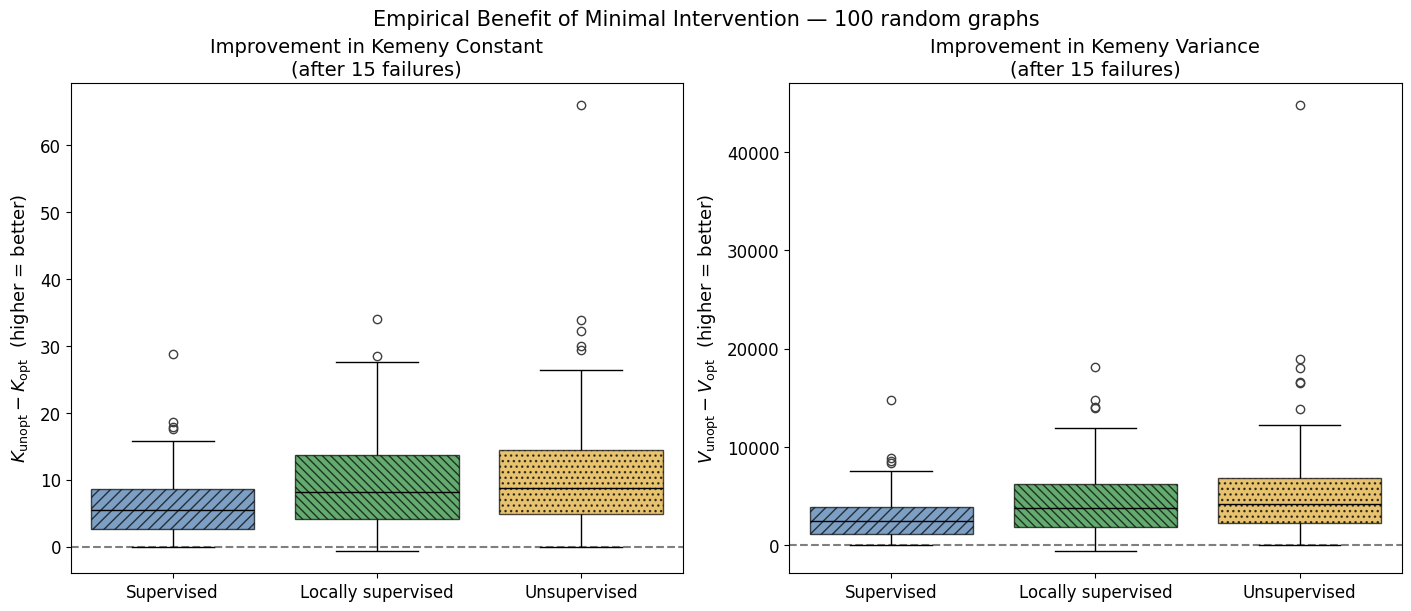

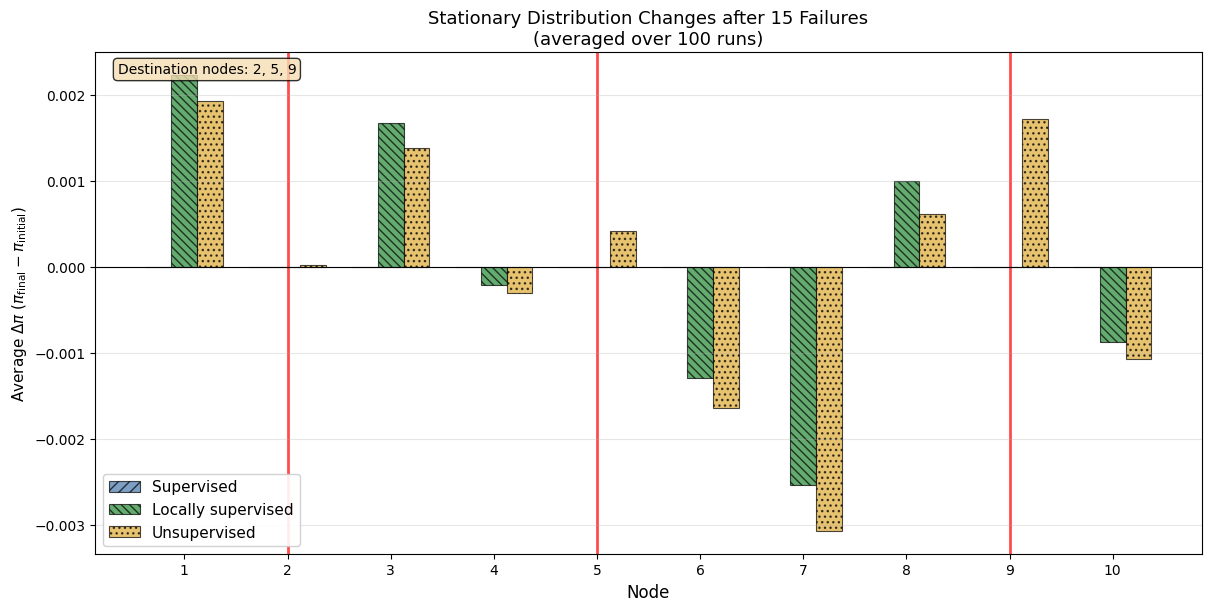

------------------------------------------------------------
Successful runs:  Supervised: 100  |  Unsupervised: 100  |  Locally supervised: 100
------------------------------------------------------------
Mean Kemeny improvement:
Method
Supervised             6.188884
Locally supervised     9.576146
Unsupervised          11.099905

Mean Variance improvement:
Method
Supervised            2845.702892
Locally supervised    4556.498839
Unsupervised          5515.999440

STATIONARY DISTRIBUTION PRESERVATION ANALYSIS
Destination nodes (1-indexed): [2 5 9]
------------------------------------------------------------

Supervised:
  At DESTINATION nodes:
    Mean |Δπ|: 0.00000000
    Max  |Δπ|: 0.00000000
  At TRANSIT nodes:
    Mean |Δπ|: 0.00000000
    Max  |Δπ|: 0.00000000
  Overall:
    Mean |Δπ|: 0.00000000

Locally supervised:
  At DESTINATION nodes:
    Mean |Δπ|: 0.00000000
    Max  |Δπ|: 0.00000000
  At TRANSIT nodes:
    Mean |Δπ|: 0.01278004
    Max  |Δπ|: 0.06554530
  Overall:
    

In [ ]:
_ = run_batch_nk_analysis_three(
    n_reps=100, N=num_nodes, p_edge=connection_prob, k_steps=15,
    W_min=W_min, W_max=W_max,
    fn=fn, projections=projections, mo=mo, hp=hp, destination_nodes=[1, 4, 8]
)